<a href="https://colab.research.google.com/github/MirandaCarou/Quantum-Open-Systems-Simulation/blob/main/Q_open_system_simuation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this section, two of the five examples in the proposed paper are implemented. Mandatory and necessary imports are ignored in this section but included in the associated notebook [enlace github]. This development had huge complications due to the deprecated software used by  \cite{Garc_a_P_rez_2020}\cite{QuantumPythonBook}. Even thought, I achieved the same results but with the updated IBM Q Experience with noise mitigation.

In [ ]:
!pip install qiskit
!pip install pylatexenc
!pip install matplotlib
!pip install qiskit-aer
!pip install qiskit_ibm_runtime
!pip install qiskit_experiments

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_experiments.library import LocalReadoutError
import matplotlib.pyplot as plt

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

# 1. Autenticación con IBM Quantum
service = QiskitRuntimeService(
    channel="ibm_quantum",
    token="d635064419fc6e72533af18d3a076d94f0b0785bbba7c1b62aa79dfe073a04e91a1f90063b80343262e376fa121f4fc269826bcdb8b7d4b52da22ef9fbf863e5"  # Opcional si ya lo configuraste con qiskit-ibm-quantum configure
)

# 2. Selección de backend real (primitivas)
backend_real = service.backend("ibm_sherbrooke")

<ipython-input-77-3a95190080e8>:6: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, ibm_cloud will be the only valid channel. For information on migrating to the new IBM Quantum Platform on the "ibm_cloud" channel, review the migration guide https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp .
  service = QiskitRuntimeService(


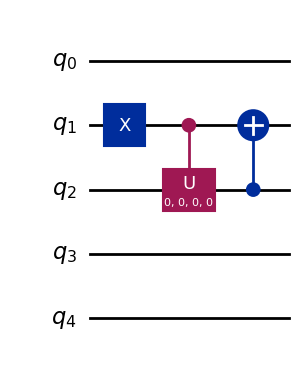

In [ ]:
q = QuantumRegister(5, name='q')
circuit = QuantumCircuit(q)

system = 1
environment = 2
theta = 0.0


circuit.x(q[system])
# Notice the extra factor 2 due to how qiskit defines the unitary angles
circuit.cu(theta, 0.0, 0.0, 0.0, q[system], q[environment])
circuit.cx(q[environment], q[system])

circuit.draw(output='mpl')

In [ ]:
!pip install qiskit_ibm_provider

This example it is related with  the Jaynes-Cumming model. I am going to simulate it along with the Markovianity of the dynamics depending on the coupling strength, explaining every step.

We must take into consideration $\theta = \arccos{c_1}(t)$ with

\begin{align*}
c_1(t) = e^{-\lambda t/2}\left[\cosh\left(\frac{\lambda t}{2}\sqrt{1-2R}\right) + \frac{1}{\sqrt{1-2R}}\sinh\left(\frac{\lambda t}{2}\sqrt{1-2R}\right)\right].
\end{align*}
In the first step, we are going to write a function called $\textbf{$c_1(t)$}$. This function should admit an extra parameter $\mathbf{R}$ and return the correct value for $R > 1/2$ and $R < 1/2$. Then, we must write another function that returns the \textbf{amplitude damping channel} given the values of $\mathbf{R}$ and $\mathbf{t}$. After that, I chose some values of $\mathbf{R}$. It is important to notice that there should be values above and below $1/2$. For each value, I simulated the amplitude damping channel at several values of $t$ and I measured the probability for the atom to be in the excited state $|1>$

In [ ]:
def c1(R,t):

    if R < 0.5:
        c1 = np.exp(- t / 2.0) * (np.cosh(t * np.sqrt(1.0 - 2.0 * R) / 2.0) + 1.0 / np.sqrt(1.0 - 2.0 * R) * np.sinh(t * np.sqrt(1.0 - 2.0 * R) / 2.0))
    else:
        c1 = np.exp(- t / 2.0) * (np.cos(t * np.sqrt(2.0 * R - 1.0) / 2.0) + 1.0 / np.sqrt(2.0 * R - 1.0) * np.sin(t * np.sqrt(2.0 * R - 1.0) / 2.0))

    return c1

In [ ]:
def amplitude_damping_channel(q, c, sys, env, R, t):
    circuit = QuantumCircuit(q, c)
    theta = np.arccos(c1(R, t))

    circuit.cu(2.0 * theta, 0.0, 0.0, 0.0, q[sys], q[env])
    circuit.cx(q[env], q[sys])
    circuit.measure(q[sys], c[0])

    return circuit

In [ ]:
def initial_state(q, sys):
    circuit = QuantumCircuit(q)
    circuit.x(q[sys])

    return circuit

So, with this functions the amplitude damping channel was simulated. First, the parameters must be declared. `SHOTS = 8192` which defines the number of measurements to obtain significant statistic results and `R_values` which contain different damping values, from values with fast decay and string damping $0.1, 0.2$ to values with slow decay and weak damping $100.0, 400.0$. For each value of $R$ the evolution times are calculated in `T_values`, which will captured the system dynamics. 5 qubits are used in this example.

After that, the quantum circuits are constructed, combining the initial state with the evolution of the damping channel. The lost of the qubits energy to the environment its modulated by the channel using controlled gates which depends in $R$ and $t$. We must notice that a set of circuits its generated for each parameter combination.

In [ ]:
SHOTS = 8192

# The values for R and corresponding times
R_values = [0.1, 0.2, 100.0, 200.0, 400.0]
npoints = 30
t_values = {}
for R in R_values:
    t_values[R] = np.linspace(0.0, 6.0 * np.pi / np.sqrt(abs(2.0 * R - 1.0)), npoints)

# We create the quantum circuits
q = QuantumRegister(5, name="q")
c = ClassicalRegister(1, name="c")

## Indices of the system and environment qubits
sys = 1
env = 2

circuits = {}
for R in R_values:
    circuits[R] = []
    for t in t_values[R]:
        # Create the initial state circuit
        initial_circuit = initial_state(q, sys)
        # Create the amplitude damping channel circuit
        damping_circuit = amplitude_damping_channel(q, c, sys, env, R, t)
        # Compose the circuits using the 'compose' method
        initial_circuit.compose(damping_circuit, qubits=q, clbits=c, inplace=True)
        # Append the combined circuit
        circuits[R].append(initial_circuit)

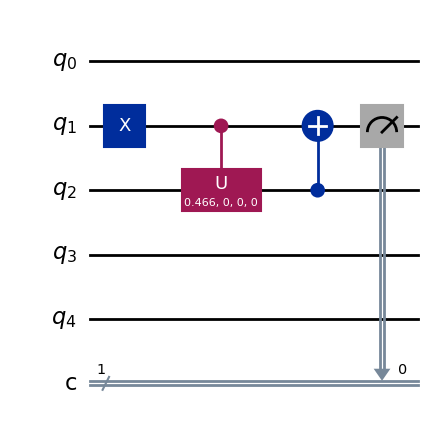

In [ ]:
circuits[0.2][1].draw(output='mpl')


ValueError: num must be an integer with 1 <= num <= 4, not 5

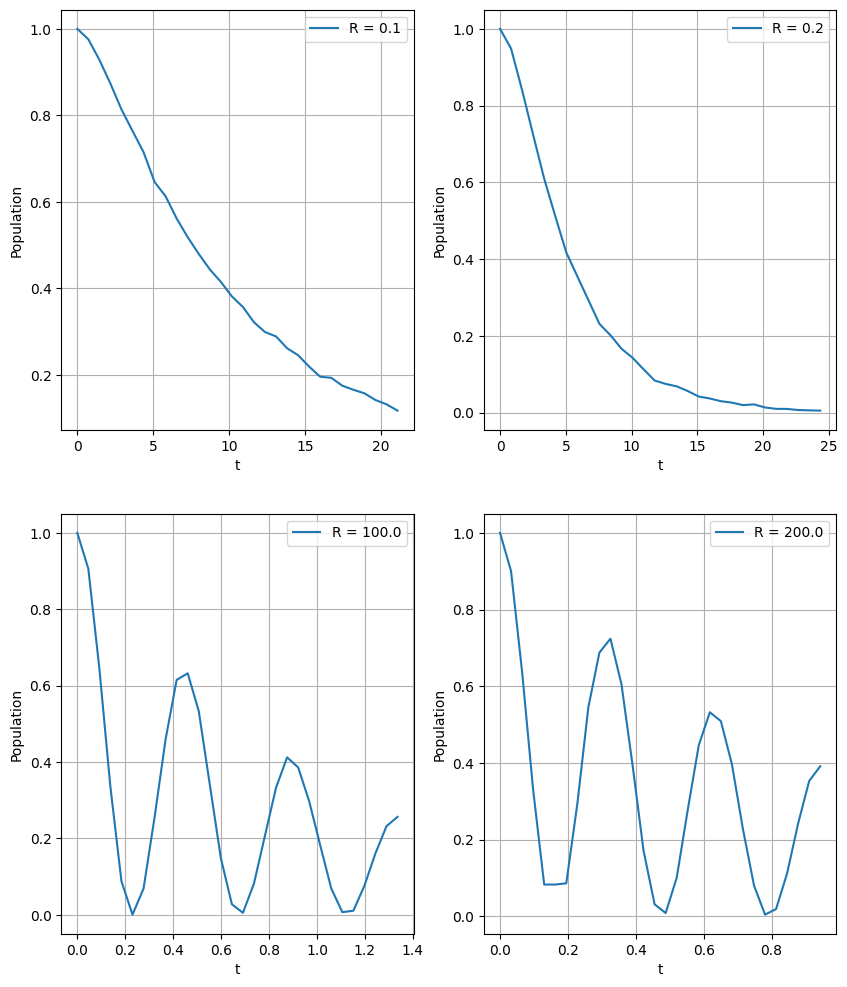

In [ ]:
# Execute the circuits on the local simulator
backend =  AerSimulator()


jobs_sim = {}
for R in R_values:
    jobs_sim[R] = backend.run(circuits[R], shots=SHOTS)  # Using run instead of execute

# Analyse the outcomes
populations_sim = {}
for R in R_values:
    populations_sim[R] = []
    current_job_res = jobs_sim[R].result()
    for i in range(npoints):
        counts = current_job_res.get_counts(i)
        if '1' in counts:
            sm = counts['1']/float(SHOTS)
        populations_sim[R].append(sm)

# Plot the results
fig_idx = 221
plt.figure(figsize=(10,12))
for R in R_values:
    plt.subplot(fig_idx)
    plt.plot(t_values[R], populations_sim[R], label=f"R = {R}")
    plt.xlabel('t')
    plt.ylabel('Population')
    plt.legend()
    fig_idx += 1
    plt.grid()


When this circuits are executed, they shown how the probability of measure $|1>$ decay with the time. When $R$ is low, **the decay is accelerated**, when $R$ is high **the decay is retarded**, which reflect the different regimes of interaction between the system and the environment.


#### **Without non-Markovianity witness**

In the based course, a real **IBM Quantum devic**e to implement the amplitude damping channel is used but an alternative approximation through virtual simulation with controlled noise was implemented in the following example,  due to the incompatibility between Qiskit versions. This strategy reproduce faithfully the decoherence effects characteristics in the real devices but with  more experimental control and without including non-Markovian witness.

Th code implements a amplitude damping channel simulation with active error mitigation incorporated by means of a three steps structural protocol.

1. **Step 1**: Noise characterisation using `LocalReadoutError` to build the mitigation matrix.
2. **Step 2**: Transpiled circuit execution. This circuits simulates different damping regimes, `R_values = [0.2, 100.0, 200.0, 400.0]`, where each circuit incorporate the evolution generated by the `amplitude_damping_channel` function
3. **Step 3**: Statistical correction of measurement probabilities $|1>$ by post-processing techniques based on the mitigation matrix.


The results demonstrate the transition between Markovian regimes and non-Markovian regimes, validating the efficiency of the mitigation scheme implemented by (\textbf{apply\_mitigation}) . This mitigation is obtained by systematically reduce the read errors without modify the subjacent physic of the model. In the following figure we can observe a comparative between the results obtained with a digital quantum simulator and a quantum noise simulator but with the error mitigation model applied.

In [ ]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit import transpile
import numpy as np
import matplotlib.pyplot as plt

# 1. Obtener el modelo de ruido de un backend real
noise_model = NoiseModel.from_backend(backend_real)

# 2. Configurar el simulador con ruido
backend = AerSimulator(
    noise_model=noise_model,
    basis_gates=noise_model.basis_gates
)

<ipython-input-99-040631637c79>:12: DeprecationWarning: Leaving `dataframe` unset or setting it to `False` for `ExperimentData.analysis_results` is deprecated as of qiskit-experiments 0.9.0. Future releases may change the default to `True` and remove the option to set the value to `False`.
  mitigator = exp_data.analysis_results(0).value
<ipython-input-99-040631637c79>:12: DeprecationWarning: Accessing analysis results via a numerical index is deprecated and will be removed in a future release. Use the ID or name of the analysis result instead.
  mitigator = exp_data.analysis_results(0).value


Mitigation matrix: <bound method LocalReadoutMitigator.mitigation_matrix of <qiskit_experiments.data_processing.mitigation.local_readout_mitigator.LocalReadoutMitigator object at 0x7ecbcdb21210>>


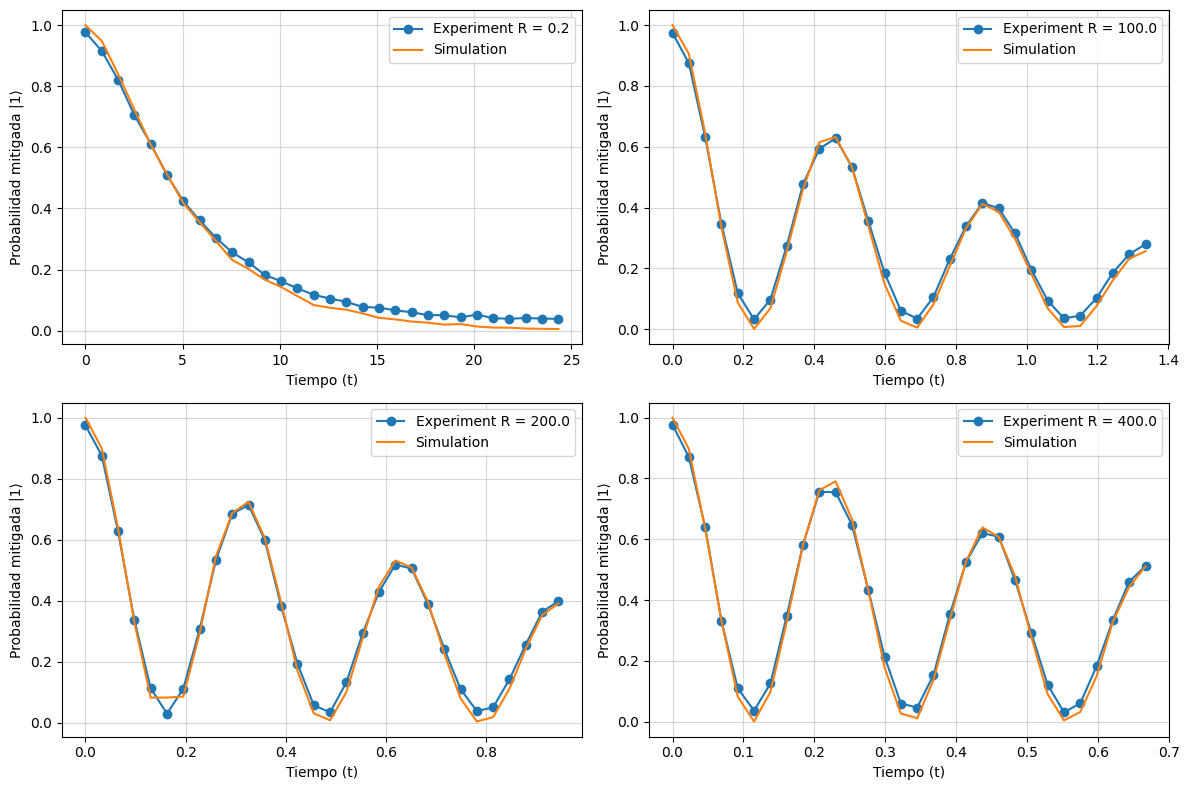

In [ ]:
# 1. Configuración del backend
#backend = AerSimulator()
SHOTS = 8192
qubit_list = [1]  # Qubit a calibrar

# 2. Función mejorada para obtener el mitigador
def get_readout_mitigator(qubits, backend, shots):
    """Obtiene el mitigador de errores de lectura de forma compatible"""
    try:
        exp = LocalReadoutError(physical_qubits=qubits)
        exp_data = exp.run(backend, shots=shots).block_for_results()
        mitigator = exp_data.analysis_results(0).value
        print("Mitigation matrix:", getattr(mitigator, "mitigation_matrix", None))
        return mitigator


    except Exception as e:
        print(f"Error obteniendo mitigador: {e}")
        return None

# 3. Obtener el mitigador
mitigator = get_readout_mitigator(qubit_list, backend, SHOTS)

# 4. Función mejorada para aplicar mitigación
def apply_mitigation(counts, mitigator):
    """Aplica mitigación de errores si el mitigador está disponible"""
    if mitigator is None:
        return counts

    if hasattr(mitigator, 'apply'):
        return mitigator.apply(counts)
    elif hasattr(mitigator, 'readout_fidelity_matrix'):
        matrix = mitigator.readout_fidelity_matrix()
        vec = np.array([counts.get('0', 0), counts.get('1', 0)], dtype=float)
        total = sum(vec)
        if total == 0:
            return counts
        vec = vec / total
        mitigated = matrix @ vec
        return {
            '0': mitigated[0] * total,
            '1': mitigated[1] * total
        }

    return counts

# 5. Generar circuitos de ejemplo (reemplaza con tus circuitos)
R_values = [0.2, 100.0, 200.0, 400.0]
npoints = 30
t_values = {R: np.linspace(0.0, 6.0 * np.pi / np.sqrt(abs(2.0 * R - 1.0)), npoints) for R in R_values}


# 6. Ejecutar experimentos y aplicar mitigación
populations = {}
for R in R_values:
    transpiled_circs = transpile(circuits[R], backend)
    result = backend.run(transpiled_circs, shots=SHOTS).result()

    populations[R] = []
    for i in range(npoints):
        raw_counts = result.get_counts(i)
        mitigated_counts = apply_mitigation( raw_counts, mitigator)
        sm = mitigated_counts.get('1', 0) / sum(mitigated_counts.values())
        populations[R].append(sm)

# 7. Visualización
plt.figure(figsize=(12, 8))
for idx, R in enumerate(R_values, 1):
    plt.subplot(2, 2, idx)
    plt.plot(t_values[R], populations[R], 'o-', label=f'Experiment R = {R}')
    plt.plot(t_values[R], populations_sim[R], label='Simulation')
    plt.xlabel('Tiempo (t)')
    plt.ylabel('Probabilidad mitigada |1⟩')
    plt.grid(alpha=0.5)
    plt.legend()

plt.tight_layout()
plt.show()

#### **Example with non-Markovianity witness**

The results we presented in this work allow us to introduce for the first time a witness of non-Markovianity in the same spirit of entanglement witnesses presented.

This witness is given by the probability of measuring the system and the ancilla in state:
$$
|\phi^+><\phi^+| = \frac{1}{4}\left(
\mathbb{I} \otimes \mathbb{I} +
\sigma_x \otimes \sigma_x -
\sigma_y \otimes \sigma_y +
\sigma_z \otimes \sigma_z
\right)
$$
The following circuit allows for the measurement of the corresponding  observables. In this case, a function which, for a given witness observable - $R$ and $t$ - returns the corresponding circuit.

In [ ]:
def amplitude_damping_channel_witness(q, c, sys, env, anc, observable, R, t):
    ad = QuantumCircuit(q, c)

    # Asegurarse que R es float
    R_float = float(R)

    # Rotation angle
    theta = 2.0 * np.arccos(c1(R_float, t))

    # Resto del código permanece igual...
    # Channel
    # Added the missing gamma argument (0.0 in this case)
    ad.cu(theta, 0.0, 0.0, 0.0, q[sys], q[env])
    ad.cx(q[env], q[sys])

    # Measurement of the corresponding observable
    if observable == 'xx':
        ad.h(sys)
        ad.h(anc)
    elif observable == 'yy':
        ad.sdg(sys)
        ad.h(sys)
        ad.sdg(anc)
        ad.h(anc)
    ad.measure(sys,c[0])
    ad.measure(anc,c[1])

    return ad

# We set the initial entangled state separately
def initial_state_witness(q, sys, anc):

    # Create circuit
    ic = QuantumCircuit(q)

    # System and ancilla in |\psi^+>
    ic.h(q[sys])
    ic.cx(q[sys], q[anc])

    return ic



In [ ]:
SHOTS = 8192

# The values for R and corresponding times,
# as well as the observables needed for the witness
observables = ['xx', 'yy', 'zz']
R_values = [0.2, 100.0, 200.0, 400.0]
npoints = 30
t_values = {}
for R in R_values:
    t_values[R] = np.linspace(0.0, 6.0 * np.pi / np.sqrt(abs(2.0 * R - 1.0)), npoints)

# We create the quantum circuits
q = QuantumRegister(5, name="q")
c = ClassicalRegister(2, name="c")

## Indices of the system, environment and ancillary qubits
sys = 1
env = 2
anc = 3



circuits = {}
for R in R_values:
    circuits[R] = {}
    for observable in observables:
        circuits[R][observable] = []
        for t in t_values[R]:
            # Create the initial state circuit for witness
            initial_circuit = initial_state_witness(q, sys, anc)
            # Create the amplitude damping channel circuit for witness
            damping_circuit = amplitude_damping_channel_witness(q, c, sys, env, anc, observable, R, t)
            # Compose the circuits using the 'compose' method
            initial_circuit.compose(damping_circuit, qubits=q, clbits=c, inplace=True)
            # Append the combined circuit
            circuits[R][observable].append(initial_circuit)

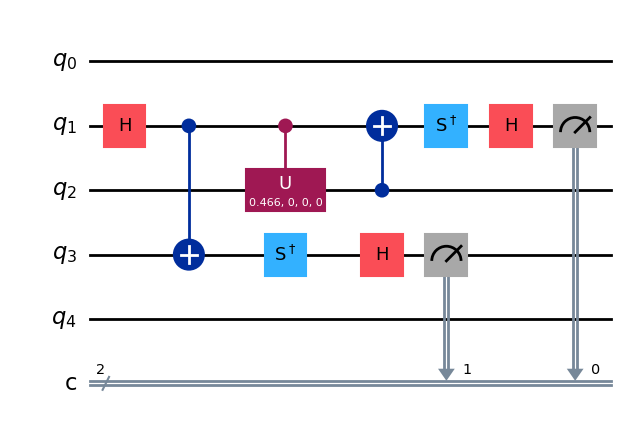

In [ ]:
circuits[0.2]['yy'][1].draw(output='mpl')

The `amplitude_damping_channel_witness`  measure the correlation between the system and the ancilla qubit for non-Markovianity witness. First, the rotation angle `theta` was calculated using `c1(R, t)`. After that,with an unitary controlled gate `cu` with angle `theta`, the environment and system qubits was implemented, following by a `CNOT` for the evolution implementation of the channel. Furthermore, depending on the specified observable (‘xx’ or ‘yy’), a `Hadamard` (h) and `phase` (sdg) gates are added to transform to the appropriate measurement basis before measuring the system and ancilla qubits in the classical bits c[0] and c[1], respectively.

This circuit allow us to study how the quantum information is degraded due to the damping system-environment, with $R$ controlling the damping rate and $t$ the time evolution. The election of the observables enable the detection of non-Markovianity signatures.

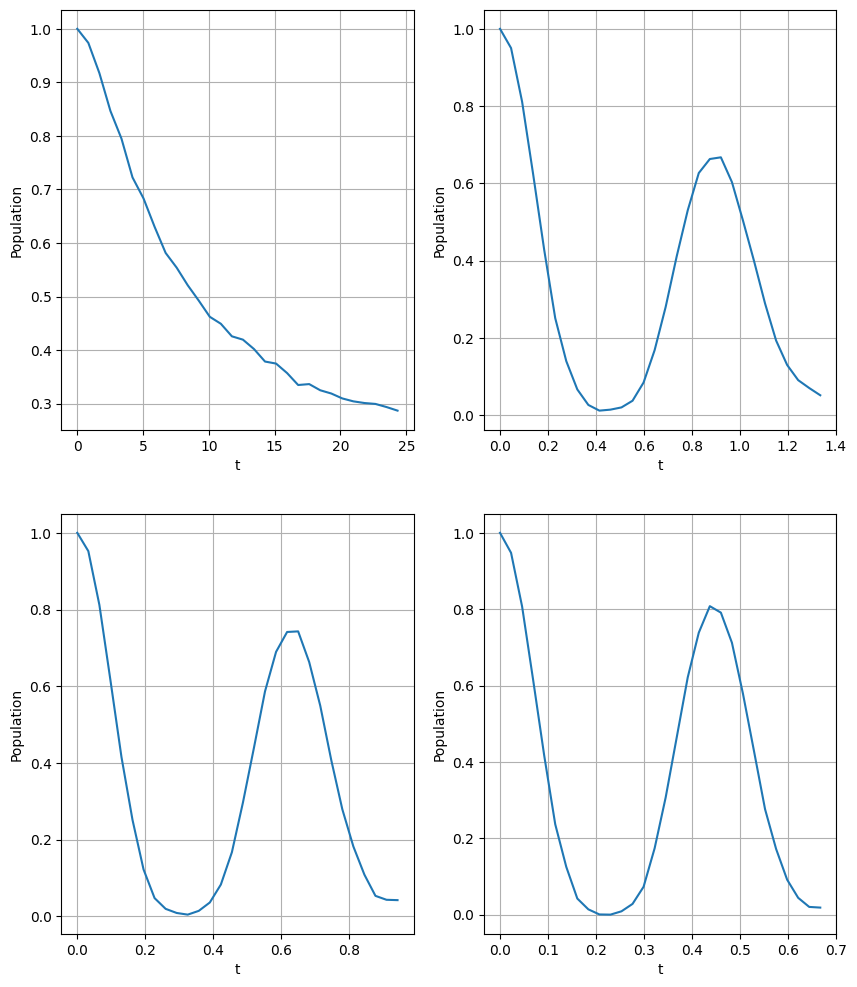

In [ ]:
backend = AerSimulator()

jobs_sim = {}
for R in R_values:
    jobs_sim[R] = {}
    for observable in observables:
        jobs_sim[R][observable] = backend.run(circuits[R][observable], shots=SHOTS)


# Analyse the outcomes
## Compute expected values
expected_sim = {}
for R in R_values:
    expected_sim[R] = {}
    for observable in observables:
        expected_sim[R][observable] = []
        current_job_res = jobs_sim[R][observable].result()
        for i in range(npoints):
            counts = current_job_res.get_counts(i)
            expc = 0.0
            for outcome in counts:
                if outcome[0] == outcome[1]:
                    expc += counts[outcome]/float(SHOTS)
                else:
                    expc -= counts[outcome]/float(SHOTS)
            expected_sim[R][observable].append(expc)

## Compute witness
witness_sim = {}
for R in R_values:
    witness_sim[R] = []
    for i in range(npoints):
        w = 0.25*(1.0+expected_sim[R]['xx'][i]-expected_sim[R]['yy'][i]+expected_sim[R]['zz'][i])
        witness_sim[R].append(w)

# Plot the results
fig_idx = 221
plt.figure(figsize=(10,12))
for R in R_values:
    plt.subplot(fig_idx)
    plt.plot(t_values[R], witness_sim[R])
    plt.xlabel('t')
    plt.ylabel('Population')
    fig_idx += 1
    plt.grid()


In this case, the dynamics with the witness for the same values of $R$ and $t$ as in task 3 are simulated. To do so, the circuits for the three observables are ran:
$$
\sigma_x \otimes \sigma_x, \quad
\sigma_y \otimes \sigma_y, \quad \text{and} \quad
\sigma_z \otimes \sigma_z
$$
and also, their expected values are computed. This allow us  to compute the value of the witness as:
$$
\frac{1}{4}\left(1 + \langle \sigma_x \otimes \sigma_x \rangle - \langle \sigma_y \otimes \sigma_y \rangle + \langle \sigma_z \otimes \sigma_z \rangle\right)
$$

When $R = 0.2$ the witness decrease monotonously, which indicates a Markovian behaviour without backflow of information. Even though , for increasing values like $R \in [100, 200, 400]$, clear oscillations are observed in the witness magnitude. This manifest correlation revivals between the system and the ancilla which is a direct evidence of non-Markovianity. In the following figure we can observe a comparative between the results obtained with a digital quantum simulator and a quantum noise simulator but with error mitigation model applied.

<ipython-input-99-040631637c79>:12: DeprecationWarning: Leaving `dataframe` unset or setting it to `False` for `ExperimentData.analysis_results` is deprecated as of qiskit-experiments 0.9.0. Future releases may change the default to `True` and remove the option to set the value to `False`.
  mitigator = exp_data.analysis_results(0).value
<ipython-input-99-040631637c79>:12: DeprecationWarning: Accessing analysis results via a numerical index is deprecated and will be removed in a future release. Use the ID or name of the analysis result instead.
  mitigator = exp_data.analysis_results(0).value


Mitigation matrix: <bound method LocalReadoutMitigator.mitigation_matrix of <qiskit_experiments.data_processing.mitigation.local_readout_mitigator.LocalReadoutMitigator object at 0x7ecbc2a4e4d0>>


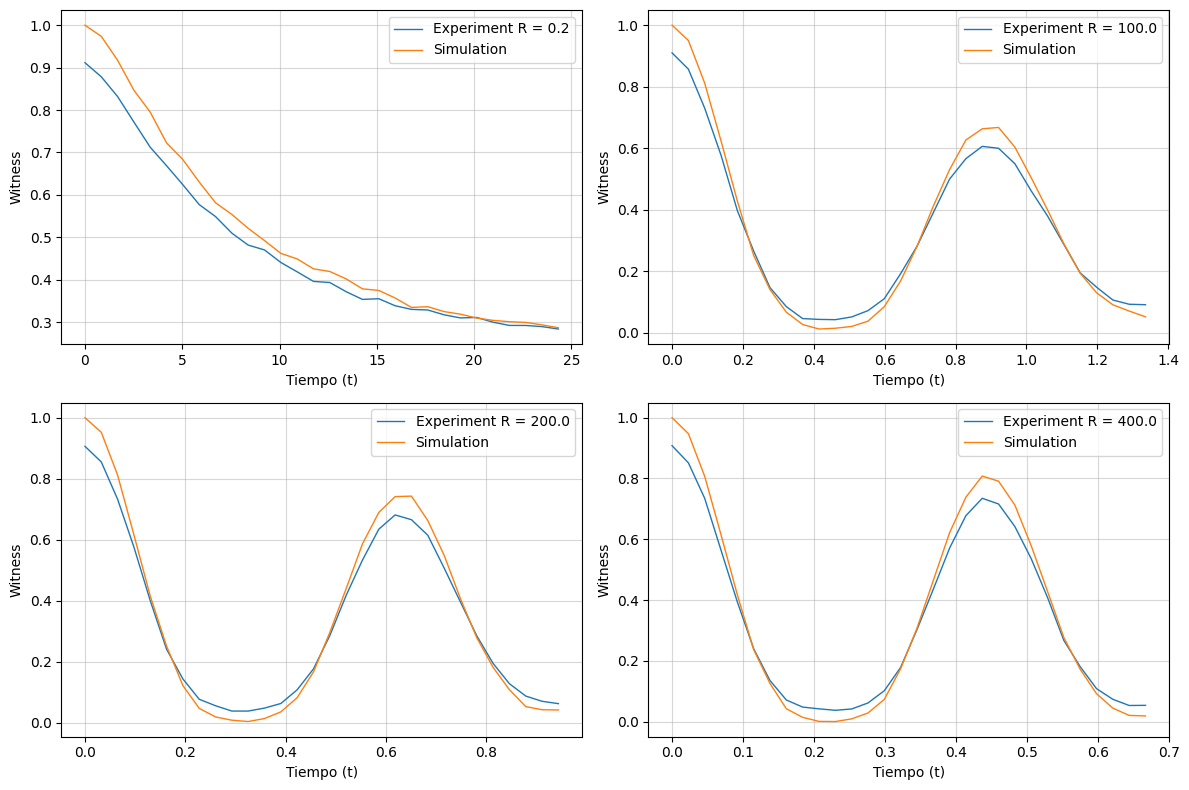

In [ ]:
noise_model = NoiseModel.from_backend(backend_real)

# 2. Configurar el simulador con ruido
backend = AerSimulator(https://drive.google.com/drive/search?q=owner%3Ame%20(type%3Aapplication%2Fvnd.google.colaboratory%20%7C%7C%20type%3Aapplication%2Fvnd.google.colab)&authuser=0
    noise_model=noise_model,
    basis_gates=noise_model.basis_gates
)
SHOTS = 8192
qubit_list = [sys, anc]  # Qubits a calibrar (sys y anc)

# 3. Obtener el mitigador para los qubits sys y anc
mitigator = get_readout_mitigator(qubit_list, backend, SHOTS)

# 5. Ejecutar experimentos para cada R y observable
jobs = {}
expected = {}
witness = {}

for R in R_values:
    jobs[R] = {}
    expected[R] = {}

    for observable in observables:
        # Ejecutar circuitos
        transpiled_circs = transpile(circuits[R][observable], backend)
        jobs[R][observable] = backend.run(transpiled_circs, shots=SHOTS)

        # Procesar resultados con mitigación
        expected[R][observable] = []
        result = jobs[R][observable].result()

        for i in range(npoints):
            counts = result.get_counts(i)
            mitigated_counts = apply_mitigation(counts, mitigator)

            # Calcular valor esperado
            expc = 0.0
            for outcome in mitigated_counts:
                if outcome[0] == outcome[1]:  # Compara los bits de sys y anc
                    expc += mitigated_counts[outcome]/float(SHOTS)
                else:
                    expc -= mitigated_counts[outcome]/float(SHOTS)
            expected[R][observable].append(expc)

    # Calcular witness para cada punto temporal
    witness[R] = []
    for i in range(npoints):
        w = 0.25*(1.0 + expected[R]['xx'][i] - expected[R]['yy'][i] + expected[R]['zz'][i])
        witness[R].append(w)

# 6. Visualización de resultados
plt.figure(figsize=(12, 8))
for idx, R in enumerate(R_values, 1):
    plt.subplot(2, 2, idx)
    plt.plot(t_values[R], witness[R], label=f'Experiment R = {R}',  linewidth=1)
    plt.plot(t_values[R], witness_sim[R], label='Simulation', linewidth=1)
    plt.xlabel('Tiempo (t)')
    plt.ylabel('Witness')
    plt.grid(alpha=0.5)
    plt.legend()

plt.tight_layout()
plt.show()

Both highlight that this type of analysis allow us to distinguish between dissipative regimes and validate theoretical quantum channels models with memory through accessible platforms as IBM Quantum Platform (referred as IBM Q Experience). In particular, this witness is a great operational tool to quantify information retro-flow from the environment.